<a href="https://colab.research.google.com/github/EiffL/Tutorials/blob/aion/FoundationModels/AION/Tutorial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##### Copyright 2026 Francois Lanusse

Licensed under the Apache License, Version 2.0 (the "License");

# Tutorial: From Galaxy Surveys to a Multimodal Embedding Space with AION-1

Author: [@EiffL](https://github.com/EiffL) (Francois Lanusse)

In this tutorial we use **[AION-1](https://github.com/PolymathicAI/AION)**, a large
multimodal foundation model for astronomy, to build a **shared embedding space** for
galaxy images and galaxy spectra — and then use that space to do science:

- **Similarity search**: retrieve galaxies that look alike, from their image or their spectrum.
- **Cross-modal retrieval**: given the *image* of a galaxy, find its *spectrum* in a haystack of thousands.
- **Physical parameter estimation**: predict redshift from images alone with a simple k-NN regressor.

---

### 🗺️ How this tutorial works

This notebook is the two ends of a sandwich, and *you* provide the middle:

1. **Part I & II (this notebook)** — stream a multimodal galaxy dataset from the
   Hugging Face Hub and turn raw images and spectra into AION-1 embeddings.
2. **Intermission (on the cluster)** — AION embeddings are *sequences* of vectors.
   You will train a small **contrastive pooling module** that collapses each sequence
   into a single vector, using the training code in this repository (see the
   [README](https://github.com/EiffL/Tutorials/blob/aion/FoundationModels/AION/README.md)),
   with experiment tracking on [Weights & Biases](https://wandb.ai).
3. **Part III (this notebook)** — load your best model back from wandb and use the
   learned embeddings for retrieval and physics.

---

### 🔍 Learning objectives

- Load and prepare data from a streamed Hugging Face dataset
- Use AION-1 to compute embeddings for images and spectra
- Adapt a frozen foundation model to a new task by training a small head on top
- Evaluate an embedding space: similarity search, cross-modal retrieval, k-NN regression

---

### ⚙️ Instructions for enabling GPU access

By default, Colab notebooks start without acceleration. To make sure that the runtime is
configured for using GPUs, go to `Runtime > Change runtime type`, and select a GPU in
`Hardware Accelerator`.

---

### 📦 Installing dependencies

In [ ]:
# Install AION and the tutorial dependencies
%pip install --quiet --upgrade polymathic-aion datasets lightning wandb scikit-learn ipywidgets

# The `aion_contrastive` package (the pooling module you will train in this
# tutorial) lives in this repository; on Colab we need to fetch it.
try:
    import aion_contrastive  # noqa: F401
except ImportError:
    !git clone --depth 1 -b aion https://github.com/EiffL/Tutorials
    %cd Tutorials/FoundationModels/AION

## Part I: The data

We use a cross-match between three public surveys, packaged as the Hugging Face dataset
[`EiffL/desi_legacysurvey_xmatch`](https://huggingface.co/datasets/EiffL/desi_legacysurvey_xmatch)
(95,895 galaxies, ~92 GB):

- **Legacy Survey DR10 imaging**: 160×160 pixel cutouts in the *g, r, i, z* bands
  (plus an RGB preview for display);
- **DESI spectra**: flux, inverse variance, mask and wavelength arrays;
- **PROVABGS catalog properties**: redshift, stellar mass, star formation rate...
  which we carry along **only for evaluation** — they are never used for training.

The full dataset is far too large to download here, but it does not need to be:
`datasets` can **stream** it, fetching rows over the network as we iterate. We will
only ever touch the first few thousand galaxies.

In [ ]:
N_GALAXIES = 2048  # how many galaxies to stream and embed
BATCH_SIZE = 32  # batch size for the AION forward passes

In [ ]:
import io
import itertools

import numpy as np
import matplotlib.pyplot as plt
from datasets import load_dataset, Image as HFImage
from PIL import Image as PILImage
from tqdm.auto import tqdm

# Streaming mode: nothing is downloaded ahead of time, rows arrive as we iterate
ds = load_dataset("EiffL/desi_legacysurvey_xmatch", split="train", streaming=True)
ds = ds.cast_column("rgb", HFImage())  # decode the RGB preview into a PIL image


def center_crop(x, size=96):
    c = (x.shape[-1] - size) // 2
    return x[..., c : c + size, c : c + size]


columns = {
    "image_flux": [],
    "rgb": [],
    "spectrum_flux": [],
    "spectrum_ivar": [],
    "spectrum_mask": [],
    "spectrum_lambda": [],
    "redshift": [],
    "log_mstar": [],
}

for row in tqdm(itertools.islice(iter(ds), N_GALAXIES), total=N_GALAXIES):
    # AION works on the central 96x96 pixels, so we crop right away
    columns["image_flux"].append(
        center_crop(np.asarray(row["image"]["flux"], dtype="float32"))
    )
    columns["rgb"].append(np.asarray(row["rgb"].convert("RGB")))
    spec = row["spectrum"]
    columns["spectrum_flux"].append(np.asarray(spec["flux"], dtype="float32"))
    columns["spectrum_ivar"].append(np.asarray(spec["ivar"], dtype="float32"))
    columns["spectrum_mask"].append(np.asarray(spec["mask"], dtype=bool))
    columns["spectrum_lambda"].append(np.asarray(spec["lambda"], dtype="float32"))
    columns["redshift"].append(row["Z_HP_provabgs"])
    columns["log_mstar"].append(row["LOG_MSTAR_provabgs"])

data = {k: np.stack(v) for k, v in columns.items()}
{k: v.shape for k, v in data.items()}

Let's have a look at a few of the galaxies we just fetched:

In [ ]:
fig, axes = plt.subplots(4, 4, figsize=(8, 8.5))
for ax, img, z in zip(axes.flat, data["rgb"], data["redshift"]):
    ax.imshow(img)
    ax.set_title(f"z = {z:.3f}", fontsize=9)
    ax.axis("off")
fig.suptitle("Legacy Survey images, labeled by PROVABGS redshift", y=0.99)
plt.tight_layout();

... and at the DESI spectrum of one of them:

In [ ]:
k = 0  # try a few different galaxies!

fig, (ax1, ax2) = plt.subplots(
    1, 2, figsize=(13, 3.5), gridspec_kw={"width_ratios": [1, 3.5]}
)
ax1.imshow(data["rgb"][k])
ax1.axis("off")
ax1.set_title(f"galaxy {k}")

good = ~data["spectrum_mask"][k]
ax2.plot(data["spectrum_lambda"][k][good], data["spectrum_flux"][k][good], lw=0.3)
ax2.set_xlabel("observed wavelength [Å]")
ax2.set_ylabel("flux")
ax2.set_title(f"DESI spectrum (z = {data['redshift'][k]:.3f})");

## Part II: From data to embeddings

**AION-1** was pretrained on 39 different data modalities — images, spectra,
photometry, and scalar catalog quantities — drawn from some of the largest surveys in
astronomy, cross-matched in the
[Multimodal Universe](https://github.com/MultimodalUniverse/MultimodalUniverse):

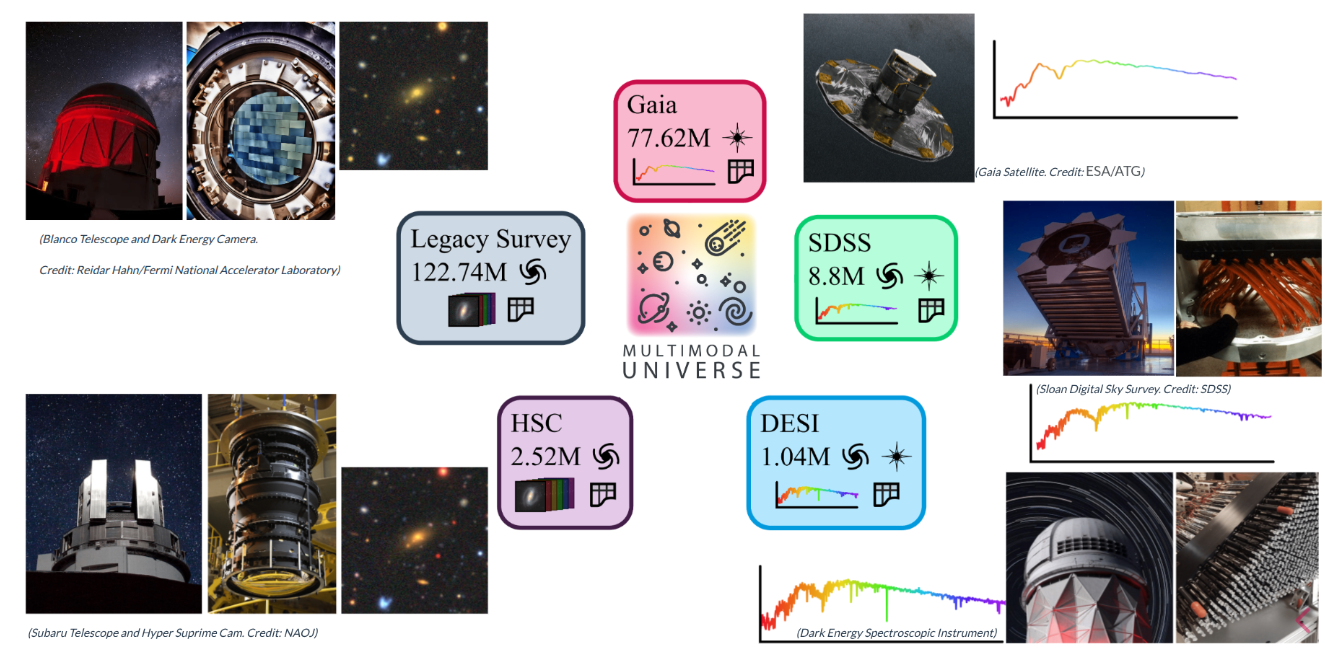

Each modality has a *typed* wrapper in `aion.modalities` (here we need
`LegacySurveyImage` and `DESISpectrum`) which keeps track of the metadata AION
expects.

Under the hood, AION first converts each modality into a short sequence of
discrete **tokens**, using modality-specific **codecs** — learned compression schemes
that translate every kind of data into AION's common language (and back):

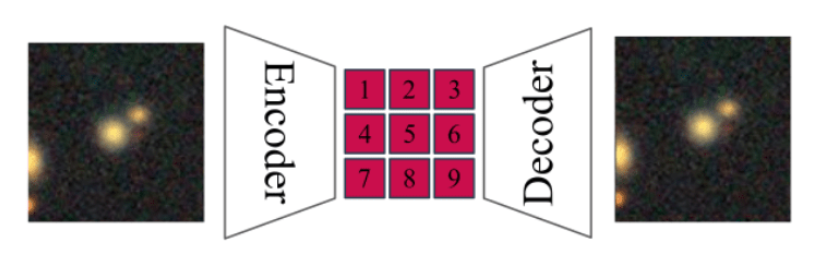

The token sequences of all input modalities are then processed together by a large
**transformer encoder**, whose outputs are the rich feature vectors — the
**embeddings** — that we are after in this tutorial:

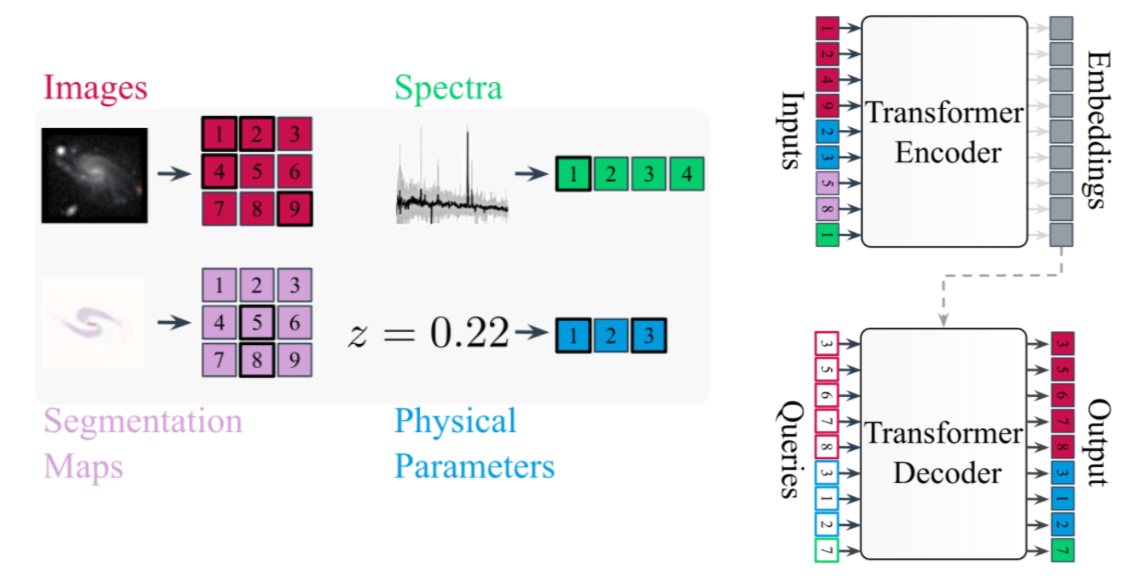

We won't dwell on the tokenization machinery here (the
[AION tutorial](https://colab.research.google.com/github/PolymathicAI/AION/blob/main/notebooks/Tutorial.ipynb)
covers it in detail, including how to decode tokens back into data and how to use the
decoder pathway for inference) — all we need to know is that

```
typed modality ──codec──> tokens ──encoder──> embeddings
```

and the two steps are two lines of code. Let's load the model and its codecs:

In [ ]:
import torch
from aion.model import AION
from aion.codecs import CodecManager
from aion.modalities import LegacySurveyImage, DESISpectrum

torch.set_grad_enabled(False)  # inference only in this notebook
device = "cuda" if torch.cuda.is_available() else "cpu"

model = AION.from_pretrained("polymathic-ai/aion-base").to(device).eval()
codec_manager = CodecManager(device=device)

Here is the full journey from raw data to embeddings, for a single galaxy image:

In [ ]:
image = LegacySurveyImage(
    flux=torch.tensor(data["image_flux"][:1], device=device),
    bands=["DES-G", "DES-R", "DES-I", "DES-Z"],
)

tokens = codec_manager.encode(image)  # typed image -> tokens
embedding = model.encode(tokens, num_encoder_tokens=600)  # tokens -> embeddings

print("Embedding of one galaxy image:", embedding.shape)

Note the shape: the embedding of a galaxy image is not one vector but a
**sequence of 576 vectors** (one 768-dimensional vector per 4×4 pixel patch of the
image). A spectrum similarly becomes a sequence of 273 vectors. Keep this in mind —
it is about to become the central problem of this tutorial.

Let's now compute embeddings for our whole galaxy sample, for images and spectra
separately (a few minutes on a Colab GPU):

In [ ]:
def format_modalities(batch, device):
    """Wrap a batch of numpy arrays into typed AION modalities."""
    image = LegacySurveyImage(
        flux=torch.tensor(batch["image_flux"], device=device),
        bands=["DES-G", "DES-R", "DES-I", "DES-Z"],
    )
    spectrum = DESISpectrum(
        flux=torch.tensor(batch["spectrum_flux"], device=device),
        ivar=torch.tensor(batch["spectrum_ivar"], device=device),
        mask=torch.tensor(batch["spectrum_mask"], device=device),
        wavelength=torch.tensor(batch["spectrum_lambda"], device=device),
    )
    return image, spectrum


image_tokens, spectrum_tokens = [], []
for i in tqdm(range(0, N_GALAXIES, BATCH_SIZE)):
    batch = {k: v[i : i + BATCH_SIZE] for k, v in data.items()}
    image, spectrum = format_modalities(batch, device)

    image_tokens.append(
        model.encode(codec_manager.encode(image), num_encoder_tokens=600)
        .half()
        .cpu()
    )
    spectrum_tokens.append(
        model.encode(codec_manager.encode(spectrum), num_encoder_tokens=300)
        .half()
        .cpu()
    )

image_tokens = torch.cat(image_tokens).numpy()
spectrum_tokens = torch.cat(spectrum_tokens).numpy()
print("image embeddings:   ", image_tokens.shape)
print("spectrum embeddings:", spectrum_tokens.shape)

We save everything Part III will need to disk (~2.6 GB), so that you can come
back to this notebook after training and resume without recomputing anything:

In [ ]:
np.savez(
    "aion_embeddings.npz",
    image_tokens=image_tokens,
    spectrum_tokens=spectrum_tokens,
    rgb=data["rgb"],
    redshift=data["redshift"],
    log_mstar=data["log_mstar"],
)

---

## 🛑 Intermission: train your own pooling module

Look again at those shapes: every galaxy is now `[576, 768]` numbers for its image and
`[273, 768]` for its spectrum. For everything we want to do next — similarity search,
retrieval, regression — we need **one vector per galaxy per modality**, in a space
where the image and the spectrum of the *same* galaxy land close together.

That reduction is something you are going to **learn**: a small cross-attention
pooling module (~10M parameters), trained with a contrastive CLIP-style objective on
image/spectrum pairs. The only supervision is *"this image and this spectrum belong to
the same galaxy"* — no physics labels whatsoever.

Everything you need lives in this repository, and the training runs **outside this
notebook**:

1. Read the
   [README](https://github.com/EiffL/Tutorials/blob/aion/FoundationModels/AION/README.md) —
   it explains the model, the InfoNCE loss, the config file, and how to launch:
   ```bash
   python main.py fit -c config/contrastive.yaml     # locally
   sbatch slurm.job                                  # on the cluster
   ```
2. Training uses
   [`EiffL/desi_x_ls_aion`](https://huggingface.co/datasets/EiffL/desi_x_ls_aion):
   the same AION embeddings you just computed, precomputed for all ~96k galaxies of
   the cross-match — so no GPU time is wasted re-encoding during training.
3. Monitor your runs on **wandb** (the README lists the metrics worth watching, in
   particular the cross-modal retrieval scores), and experiment: batch size, number of
   learned queries, pooler depth, learning rate...
4. When you are happy with a run, note its **run path** — the `entity/project/run_id`
   string you can read off the wandb URL of the run — and come back here.

> ⚠️ **If you are on Colab**: the local disk does not survive the session, so
> `aion_embeddings.npz` will be gone when you return. Either keep the tab alive, copy
> the file to your Drive, or simply rerun Parts I–II when you come back (~15 minutes).

---

## Part III: Science with your learned embedding space

*(Coming back after training? Run the install cell at the top of the notebook first,
then resume from here.)*

Point the notebook at your best training run:

In [ ]:
# Paste your own run path here: "entity/project/run_id", as in the wandb URL
WANDB_RUN = "eiffl/aion-contrastive/expzhwkb"

In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt

torch.set_grad_enabled(False)  # inference only (again, in case of a fresh session)
device = "cuda" if torch.cuda.is_available() else "cpu"

# Reload everything Part II saved to disk
cache = np.load("aion_embeddings.npz")
image_tokens, spectrum_tokens = cache["image_tokens"], cache["spectrum_tokens"]
rgb, redshift, log_mstar = cache["rgb"], cache["redshift"], cache["log_mstar"]
print(f"{len(image_tokens)} galaxies loaded from cache")

### Download the trained pooling module from wandb

During training, Lightning's `WandbLogger` (with `log_model: all`) uploaded every
checkpoint to wandb as a versioned **model artifact** named `model-<run_id>`, and kept
the alias `best` pointing at the checkpoint with the lowest `val/loss`. So the run path
is all we need — training may have happened on a cluster while this notebook runs on
Colab or your laptop. `load_from_checkpoint` restores both the weights and the
hyperparameters, because the `LightningModule` called `save_hyperparameters()` in its
`__init__`.

In [ ]:
import os
import wandb
from aion_contrastive import ContrastiveAlignment

wandb.login()  # will prompt for your API key if you are not logged in yet

entity_project, run_id = WANDB_RUN.rsplit("/", 1)
artifact = wandb.Api().artifact(f"{entity_project}/model-{run_id}:best", type="model")
ckpt_path = os.path.join(artifact.download(), "model.ckpt")
print("downloaded:", ckpt_path)

pooler = (
    ContrastiveAlignment.load_from_checkpoint(ckpt_path, map_location=device)
    .eval()
    .to(device)
)
print(f"pooling module parameters: {sum(p.numel() for p in pooler.parameters())/1e6:.1f} M")

### From token sequences to vectors

We can now collapse each `[576, 768]` (or `[273, 768]`) sequence into a single
768-dimensional vector with your trained module. The resulting vectors are
**L2-normalized** — they live on the unit sphere where the contrastive loss operates —
so the dot product between two embeddings *is* their cosine similarity.

In [ ]:
def pool(tokens, embed_fn, batch_size=256):
    out = []
    for i in range(0, len(tokens), batch_size):
        chunk = torch.from_numpy(tokens[i : i + batch_size]).to(device)
        out.append(embed_fn(chunk).cpu())
    return torch.cat(out).numpy()


z_image = pool(image_tokens, pooler.embed_image)
z_spectrum = pool(spectrum_tokens, pooler.embed_spectrum)
print("image vectors:   ", z_image.shape)
print("spectrum vectors:", z_spectrum.shape)

### 🔎 Similarity search in embedding space

The simplest thing to do with vector embeddings: pick a query galaxy, compute the
cosine similarity to every other galaxy, and look at the closest ones. If the space is
any good, the neighbors should share morphology, color, size... none of which was ever
labeled.

In [ ]:
from ipywidgets import interact


def show_retrievals(query_index, similarity, title, top_n=15):
    """Display the query galaxy followed by its top-N matches."""
    order = [i for i in np.argsort(similarity)[::-1] if i != query_index][:top_n]
    fig, axes = plt.subplots(4, 4, figsize=(9, 9.5))
    axes = axes.flatten()
    axes[0].imshow(rgb[query_index])
    axes[0].set_title(f"QUERY (obj {query_index})", fontsize=9, fontweight="bold")
    for ax, idx in zip(axes[1:], order):
        ax.imshow(rgb[idx])
        ax.set_title(f"obj {idx} · sim {similarity[idx]:.2f}", fontsize=8)
    for ax in axes:
        ax.axis("off")
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

In [ ]:
# @title [Run Me] Similarity by image
@interact(index=(0, 63))
def image_similarity(index=0):
    show_retrievals(
        index, z_image @ z_image[index], "Most similar galaxies — image embeddings"
    )

In [ ]:
# @title [Run Me] Similarity by spectrum
@interact(index=(0, 63))
def spectrum_similarity(index=0):
    show_retrievals(
        index,
        z_spectrum @ z_spectrum[index],
        "Most similar galaxies — spectrum embeddings",
    )

### 🔀 Cross-modal retrieval

Here is what makes this embedding space special: images and spectra live in the *same*
space, so we can query **across modalities** — below, we take the *image* embedding of
a galaxy and rank every galaxy by the similarity of its *spectrum* embedding to it.

In [ ]:
# @title [Run Me] Given this image, which galaxies have a matching spectrum?
@interact(index=(0, 63))
def cross_modal_similarity(index=0):
    show_retrievals(
        index,
        z_spectrum @ z_image[index],
        "Galaxies whose SPECTRUM best matches the query IMAGE",
    )

We can make this quantitative, and reproduce the honest end-task metric from
training: for each galaxy image, at which rank does its **own** spectrum appear among
all spectra? Random chance for top-1 would be $1/N \approx 0.05\%$.

In [ ]:
sim = z_image @ z_spectrum.T  # [N, N]: image i vs spectrum j

# Rank of the true spectrum = number of spectra scoring higher than the diagonal
rank = (sim > np.diag(sim)[:, None]).sum(axis=1)
print(f"top-1  retrieval: {100 * np.mean(rank == 0):5.1f}%")
print(f"top-10 retrieval: {100 * np.mean(rank < 10):5.1f}%")
print(f"(random chance:   {100 / len(sim):.2f}% and {1000 / len(sim):.2f}%)")

plt.figure(figsize=(5.5, 5))
plt.imshow(sim[:128, :128])
plt.xlabel("spectrum index")
plt.ylabel("image index")
plt.title("image × spectrum similarity (first 128 galaxies)")
plt.colorbar(label="cosine similarity");

That bright diagonal is the whole point of contrastive training — each image is
most similar to its own spectrum, out of thousands.

### 📈 Redshift estimation with k-NN regression

Finally, let's check how much *physics* the embedding space has absorbed. We use the
most primitive estimator imaginable: a **k-Nearest Neighbors regressor**. For a given
galaxy, find its `k` closest neighbors in embedding space and average their redshifts.
If galaxies that are close in embedding space have similar redshifts, the embedding
"knows" about redshift.

And to make it interesting, we predict redshift from the **image embeddings alone**.
Remember: neither AION's pretraining labels nor the contrastive alignment ever used
redshift — but by pulling image embeddings towards spectrum embeddings, the alignment
teaches the image side of the space what only spectra can measure precisely. This is
the classic [AstroCLIP](https://arxiv.org/abs/2310.03024) result.

In [ ]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

X_train, X_test, y_train, y_test = train_test_split(
    z_image, redshift, test_size=0.2, random_state=42
)

knn = KNeighborsRegressor(n_neighbors=10, weights="distance")
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)

In [ ]:
r2 = r2_score(y_test, y_pred)

plt.figure(figsize=(6.5, 6))
plt.scatter(y_test, y_pred, s=12, alpha=0.5)
lo, hi = 0, max(y_test.max(), y_pred.max()) * 1.05
plt.plot([lo, hi], [lo, hi], "k--", lw=1.5)
plt.xlim(lo, hi)
plt.ylim(lo, hi)
plt.xlabel("True redshift")
plt.ylabel("Predicted redshift")
plt.title(f"k-NN redshift from image embeddings alone (R² = {r2:.2f})");

## 🎉 Wrap-up

Here is the complete journey you just made:

- **Raw survey data** (images + spectra), streamed straight from the Hugging Face Hub;
- **AION-1 embeddings**: a frozen foundation model turned each modality into a
  sequence of rich feature vectors — no training required on your side;
- **A learned pooling module**: ~10M parameters that *you* trained in minutes,
  producing one vector per galaxy per modality in a shared space;
- **Science for free**: similarity search, cross-modal retrieval, and redshift
  estimation — all with embarrassingly simple estimators on top of the embeddings.

This is the core recipe for adapting foundation models: keep the big model frozen,
learn a small task-specific head, and let simple methods do the rest.

### 🏋️ Exercises

1. **Compare your runs.** If you trained several configurations, load each of them
   (just change `WANDB_RUN` and rerun Part III) — do the retrieval numbers here track
   the `val/loss` you saw on wandb?
2. **Stellar mass.** `log_mstar` is already loaded. Predict it with the same k-NN
   setup — from image embeddings, then from spectrum embeddings. Which modality
   carries more information about mass?
3. **Combine modalities.** Concatenate `z_image` and `z_spectrum` and redo the k-NN
   regression. Does the combination beat either alone?
4. **How much did training matter?** Instantiate an *untrained* pooling module
   (`pooler = ContrastiveAlignment().eval().to(device)`) and rerun Part III. How much
   of the performance comes from training vs. from the frozen AION embeddings?
5. **Scale up.** Increase `N_GALAXIES` and rerun. Which of the results above improve,
   and why?